## Project: Manchu-English Translation, Attempt 2: Pretrained manchuBERT as encoder

In [2]:
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.2 MB/s eta 0:00:00


In [3]:
BASE_DIR = '/content/drive/MyDrive/2025nn'

## Attempt 2: Pretrained encoder `manchuBERT` with decoder of stacked LSTM

In [24]:
# 🍒

import os
import json
import random
import math
import time
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModel
from sacrebleu import corpus_bleu

In [26]:
SEED = 6600
fpath = "/content/drive/MyDrive/2025nn/parallel.csv"
val_fpath = "/content/drive/MyDrive/2025nn/cathay-validation.csv"
src_col = "manchu"
tgt_col = "english"

output_fpath = "./runs/attempt2"
os.makedirs(output_fpath, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

VAL_BLEU_MAX_SAMPLES = 107


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [27]:
MAX_SRC_LEN = 128
MAX_TGT_LEN = 128
BATCH_SIZE = 8
EPOCHS = 50
LR = 2e-4
EMB_SIZE = 256
HIDDEN_SIZE = 512
NUM_LAYERS = 2
DROPOUT = 0.2
CLIP = 1.0

### Prepare Data

In [28]:
def load_splits():
    df = pd.read_csv(fpath)
    src_all = tuple(df[src_col].astype(str))
    tgt_all = tuple(df[tgt_col].astype(str))

    train_src, test_src, train_tgt, test_tgt = train_test_split(
        src_all, tgt_all, test_size=0.25, random_state=SEED
    )
    val_src, test_src, val_tgt, test_tgt = train_test_split(
        test_src, test_tgt, test_size=0.5, random_state=SEED
    )

    # val_df = pd.read_csv(val_fpath)
    # val_src = tuple(val_df[src_col].astype(str))
    # val_tgt = tuple(val_df[tgt_col].astype(str))

    return train_src, train_tgt, val_src, val_tgt, test_src, test_tgt


#### Prepare source and target tensor pairs, padding and batching

In [29]:
class PairDataset(Dataset):
    def __init__(self, src: Tuple[str, ...], tgt: Tuple[str, ...]):
        self.src = list(src)
        self.tgt = list(tgt)

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]


def collate_fn(batch, src_tok, tgt_tok):
    src_texts, tgt_texts = zip(*batch)

    src_enc = src_tok(
        list(src_texts),
        padding=True,
        truncation=True,
        max_length=MAX_SRC_LEN,
        return_tensors="pt",
    )

    tgt_enc = tgt_tok(
        list(tgt_texts),
        padding=True,
        truncation=True,
        max_length=MAX_TGT_LEN,
        return_tensors="pt",
    )

    return (
        src_enc["input_ids"],
        src_enc["attention_mask"],
        tgt_enc["input_ids"],
        tgt_enc["attention_mask"],
    )

### Place the model

#### Frozen manchuBERT

In [30]:
class ManchuBERTEncoder(nn.Module):
    def __init__(self, model_name="seemdog/manchuBERT", freeze=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_size = self.bert.config.hidden_size

        if freeze:
            for p in self.bert.parameters():
                p.requires_grad = False

    def forward(self, input_ids, attention_mask):
        if not any(p.requires_grad for p in self.bert.parameters()):
            with torch.no_grad():
                out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        else:
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state

class LSTMDecoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size, num_layers, dropout, pad_id):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            emb_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        emb = self.dropout(self.embedding(x))
        out, hidden = self.lstm(emb, hidden)
        logits = self.fc(out)
        return logits, hidden


class Seq2SeqManchuBERTLSTM(nn.Module):
    def __init__(self, encoder: ManchuBERTEncoder, decoder: LSTMDecoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

        self.enc_proj_h = nn.Linear(encoder.hidden_size, decoder.lstm.hidden_size)
        self.enc_proj_c = nn.Linear(encoder.hidden_size, decoder.lstm.hidden_size)

        self.num_layers = decoder.lstm.num_layers
        self.hidden_size = decoder.lstm.hidden_size

    # CLS embedding as conditional LM
    def init_hidden(self, enc_out):
        cls = enc_out[:, 0, :]

        h0 = torch.tanh(self.enc_proj_h(cls))
        c0 = torch.tanh(self.enc_proj_c(cls))

        # repeat across layers
        h0 = h0.unsqueeze(0).repeat(self.num_layers, 1, 1).contiguous()
        c0 = c0.unsqueeze(0).repeat(self.num_layers, 1, 1).contiguous()
        return (h0, c0)

    def forward(self, src_ids, src_mask, tgt_in):
        enc_out = self.encoder(src_ids, src_mask)
        hidden = self.init_hidden(enc_out)
        logits, _ = self.decoder(tgt_in, hidden)
        return logits


### Helper Functions

In [31]:
def shift_right(tgt_ids, bos_id, pad_id):
    """
    tgt_ids: (B, T) includes [CLS] ... [SEP] ... [PAD]
    Make decoder input: [CLS] y0 y1 ... y_{T-2}
    """
    y = tgt_ids.clone()
    y_in = y.new_full(y.shape, pad_id)
    y_in[:, 0] = bos_id
    y_in[:, 1:] = y[:, :-1]
    y_in[y == pad_id] = pad_id
    return y_in


def compute_bleu(preds: List[str], refs: List[str]) -> float:
    # sacrebleu expects list of system outputs and list of reference lists
    return corpus_bleu(preds, [refs]).score


def pretty_samples(src, ref, hyp, k=8):
    lines = []
    for i in range(min(k, len(src))):
        lines.append(
            f"SRC: {src[i]}\n"
            f"REF: {ref[i]}\n"
            f"GEN: {hyp[i]}\n"
            + "-" * 60
        )
    return "\n".join(lines)


@torch.no_grad()
def translate_greedy(model, src_sentence, src_tok, tgt_tok, max_len=MAX_TGT_LEN):
    model.eval()
    enc = src_tok(
        src_sentence,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SRC_LEN,
    ).to(device)

    enc_out = model.encoder(enc["input_ids"], enc["attention_mask"])
    hidden = model.init_hidden(enc_out)

    # BOS/EOS for English BERT tokenizer
    bos_id = tgt_tok.cls_token_id
    eos_id = tgt_tok.sep_token_id

    out_ids = [bos_id]

    for _ in range(max_len - 1):
        x = torch.tensor([out_ids], device=device)  # (1, t)
        logits, hidden = model.decoder(x, hidden)
        next_id = logits[:, -1, :].argmax(-1).item()
        if next_id == eos_id:
            break
        out_ids.append(next_id)

    return tgt_tok.decode(out_ids[1:], skip_special_tokens=True).strip()


def train_epoch(model, loader, optimizer, loss_fn, bos_id, pad_id):
    model.train()
    total = 0.0

    for src_ids, src_mask, tgt_ids, tgt_mask in loader:
        src_ids = src_ids.to(device)
        src_mask = src_mask.to(device)
        tgt_ids = tgt_ids.to(device)

        tgt_in = shift_right(tgt_ids, bos_id=bos_id, pad_id=pad_id)  # (B, T)

        logits = model(src_ids, src_mask, tgt_in)  # (B, T, V)

        # comparing logits[:,1:] to tgt_ids[:,1:]
        loss = loss_fn(
            logits[:, 1:, :].reshape(-1, logits.size(-1)),
            tgt_ids[:, 1:].reshape(-1),
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()

        total += loss.item()

    return total / max(1, len(loader))


@torch.no_grad()
def eval_loss(model, loader, loss_fn, bos_id, pad_id):
    model.eval()
    total = 0.0

    for src_ids, src_mask, tgt_ids, tgt_mask in loader:
        src_ids = src_ids.to(device)
        src_mask = src_mask.to(device)
        tgt_ids = tgt_ids.to(device)

        tgt_in = shift_right(tgt_ids, bos_id=bos_id, pad_id=pad_id)
        logits = model(src_ids, src_mask, tgt_in)

        loss = loss_fn(
            logits[:, 1:, :].reshape(-1, logits.size(-1)),
            tgt_ids[:, 1:].reshape(-1),
        )

        total += loss.item()

    return total / max(1, len(loader))


def plot_curves(history: List[Dict], out_dir: str):
    e = [h["epoch"] for h in history]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(e, [h["train_loss"] for h in history], label="Train")
    plt.plot(e, [h["val_loss"] for h in history], label="Val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(e, [h["val_bleu"] for h in history], marker="o")
    plt.title("Validation BLEU")
    plt.xlabel("Epoch")

    plt.tight_layout()
    fig_path = os.path.join(out_dir, "curves.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved plot:", fig_path)

## Main

- references:
    - https://huggingface.co/seemdog/manchuBERT
    - https://huggingface.co/google-bert/bert-base-uncased

Train: 225 | Val: 37 | Test: 38


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/594 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/421M [00:00<?, ?B/s]

Some weights of BertModel were not initialized from the model checkpoint at seemdog/manchuBERT and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 27937082


model.safetensors:   0%|          | 0.00/421M [00:00<?, ?B/s]

Epoch 01/50 |   8.6s | Train 9.547 | Val 7.447 | ValBLEU 0.00  ✓loss ✓bleu
Epoch 02/50 |   2.7s | Train 6.018 | Val 6.546 | ValBLEU 0.00  ✓loss 
Epoch 03/50 |   1.3s | Train 5.372 | Val 6.595 | ValBLEU 0.00   
Epoch 04/50 |   1.3s | Train 5.288 | Val 6.653 | ValBLEU 0.00   
Epoch 05/50 |   1.3s | Train 5.272 | Val 6.707 | ValBLEU 0.00   
Sample (val):
SRC: sarxame efici acara ba akv
REF: there is nothing worth seeing
GEN: i you
----------------------------------------
SRC: ajigan ci emu bade mutume hvwaxaha
REF: having ever since our youth grown up together
GEN: i you
----------------------------------------
SRC: bi yala muterakv ohobi
REF: this cannot be done
GEN: i you
----------------------------------------
Epoch 06/50 |   1.3s | Train 5.197 | Val 6.748 | ValBLEU 0.00   
Epoch 07/50 |   1.3s | Train 5.181 | Val 6.792 | ValBLEU 0.00   
Epoch 08/50 |   1.3s | Train 5.161 | Val 6.833 | ValBLEU 0.00   
Epoch 09/50 |   1.3s | Train 5.144 | Val 6.846 | ValBLEU 0.00   
Epoch 10/50 |   1.3

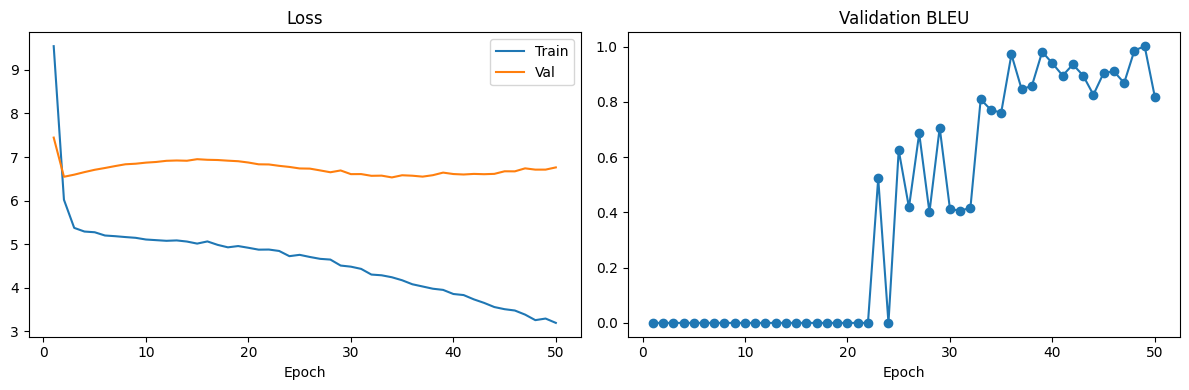

Saved plot: ./runs/attempt2/curves.png

TEST EVAL: best_val_loss.pt
Test BLEU: 1.27

Sample translations:

SRC: manggai amba tacin i bithe dabala
REF: it is the great learning
GEN: if is the of
------------------------------------------------------------
SRC: bi umai seme gisurehekv
REF: i was not saying anything
GEN: i have to
------------------------------------------------------------
SRC: doron be waliyabuci ja baita
REF: the loss of a seal is an ordinary occurrence after all
GEN: what is
------------------------------------------------------------
SRC: xi halai nun simbe aliyame tehebi
REF: cousin shih is waiting for you
GEN: i have to to
------------------------------------------------------------
SRC: jiduji loo tai tai fulu kai
REF: your venerable ladyship
GEN: i will to the
------------------------------------------------------------
SRC: yafan i dergi amargi hoxoi bade
REF: supply of pine and cedar trees in the northeast corner of the park
GEN: the the the of the
------------

In [32]:
def main():
    train_src, train_tgt, val_src, val_tgt, test_src, test_tgt = load_splits()
    print(f"Train: {len(train_src)} | Val: {len(val_src)} | Test: {len(test_src)}")

    # use hugging face AutoTokenizer
    src_tok = AutoTokenizer.from_pretrained("seemdog/manchuBERT")

    # eng tokenizer
    tgt_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
    assert tgt_tok.cls_token_id is not None and tgt_tok.sep_token_id is not None and tgt_tok.pad_token_id is not None

    bos_id = tgt_tok.cls_token_id
    eos_id = tgt_tok.sep_token_id
    pad_id = tgt_tok.pad_token_id

    train_loader = DataLoader(
        PairDataset(train_src, train_tgt),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=lambda b: collate_fn(b, src_tok, tgt_tok),
    )

    val_loader = DataLoader(
        PairDataset(val_src, val_tgt),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=lambda b: collate_fn(b, src_tok, tgt_tok),
    )

    encoder = ManchuBERTEncoder(freeze=True)
    decoder = LSTMDecoder(
        vocab_size=len(tgt_tok),
        emb_size=EMB_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        pad_id=pad_id
    )
    model = Seq2SeqManchuBERTLSTM(encoder, decoder).to(device)

    # train only decoder
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    print("Trainable params:", sum(p.numel() for p in trainable_params))

    optimizer = torch.optim.AdamW(trainable_params, lr=LR)
    loss_fn = nn.CrossEntropyLoss(ignore_index=pad_id)

    history = []
    best_val_loss = float("inf")
    best_val_bleu = -1.0

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        tr = train_epoch(model, train_loader, optimizer, loss_fn, bos_id, pad_id)
        vl = eval_loss(model, val_loader, loss_fn, bos_id, pad_id)

        # BLEU eval (greedy)
        n_eval = len(val_src) if VAL_BLEU_MAX_SAMPLES is None else min(len(val_src), VAL_BLEU_MAX_SAMPLES)
        preds = [translate_greedy(model, s, src_tok, tgt_tok) for s in val_src[:n_eval]]
        vb = compute_bleu(preds, list(val_tgt[:n_eval]))

        history.append(dict(epoch=epoch, train_loss=tr, val_loss=vl, val_bleu=vb))

        # checkpointing
        loss_mark = ""
        bleu_mark = ""

        if vl < best_val_loss:
            best_val_loss = vl
            torch.save(model.state_dict(), os.path.join(output_fpath, "best_val_loss.pt"))
            loss_mark = "✓loss"

        if vb > best_val_bleu:
            best_val_bleu = vb
            torch.save(model.state_dict(), os.path.join(output_fpath, "best_val_bleu.pt"))
            bleu_mark = "✓bleu"

        if epoch == 40:
            torch.save(model.state_dict(), os.path.join(output_fpath, "epoch_40.pt"))

        dt = time.time() - t0
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | {dt:5.1f}s | "
            f"Train {tr:.3f} | Val {vl:.3f} | ValBLEU {vb:.2f}  {loss_mark} {bleu_mark}"
        )
        if epoch % 5 == 0:
            # show samples each  5 epoch
            sample_k = min(3, n_eval)
            if sample_k > 0:
                print("Sample (val):")
                for i in range(sample_k):
                    print("SRC:", val_src[i])
                    print("REF:", val_tgt[i])
                    print("GEN:", preds[i])
                    print("-" * 40)

    # Save history
    hist_path = os.path.join(output_fpath, "history.json")
    with open(hist_path, "w", encoding="utf-8") as f:
        json.dump(history, f, indent=2)
    print("Saved history:", hist_path)

    plot_curves(history, output_fpath)

    # evaluate on testset
    def eval_on_test(ckpt_name: str):
        print("\n" + "=" * 70)
        print(f"TEST EVAL: {ckpt_name}")
        print("=" * 70)

        model.load_state_dict(torch.load(os.path.join(output_fpath, ckpt_name), map_location=device))
        model.to(device)
        model.eval()

        test_preds = [translate_greedy(model, s, src_tok, tgt_tok) for s in test_src]
        test_bleu = compute_bleu(test_preds, list(test_tgt))
        print(f"Test BLEU: {test_bleu:.2f}\n")
        print("Sample translations:\n")
        print(pretty_samples(list(test_src), list(test_tgt), test_preds, k=8))

    eval_on_test("best_val_loss.pt")
    eval_on_test("best_val_bleu.pt")
    eval_on_test("epoch_40.pt")


if __name__ == "__main__":
    main()
